In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("/kaggle/input/pima-indians-diabetes-database/diabetes.csv")
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# 1. Khởi tạo mô hình

In [11]:
# Tính tỷ lệ Outcome
outcome_counts = df['Outcome'].value_counts()
outcome_ratio = outcome_counts / len(df) * 100

print("Số lượng Outcome:")
print(outcome_counts)
print("\nTỷ lệ Outcome (%):")
print(outcome_ratio)

Số lượng Outcome:
Outcome
0    500
1    268
Name: count, dtype: int64

Tỷ lệ Outcome (%):
Outcome
0    65.104167
1    34.895833
Name: count, dtype: float64


In [12]:
# Xóa các cột _Bin nếu không cần
df = df.drop(columns=[col for col in df.columns if '_Bin' in col])
print("Số lượng NaN sau khi xóa cột _Bin:")
print(df.isna().sum())  # Kiểm tra lại, nên là 0 cho tất cả cột

Số lượng NaN sau khi xóa cột _Bin:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [13]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

# Chọn top 5 feature
selector = SelectKBest(score_func=f_classif, k=5)
selector.fit(X_train, y_train)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# Lấy tên feature đã chọn
selected_features = X.columns[selector.get_support()].tolist()
anova_scores = pd.DataFrame({'Feature': X.columns, 'F-Score': selector.scores_})
anova_scores = anova_scores.sort_values(by='F-Score', ascending=False)
print("ANOVA F-Statistic Scores:")
print(anova_scores)
print("Selected Features:", selected_features)

ANOVA F-Statistic Scores:
                    Feature     F-Score
1                   Glucose  160.769030
5                       BMI   63.378414
7                       Age   52.326951
0               Pregnancies   27.550001
6  DiabetesPedigreeFunction   14.977704
4                   Insulin    7.290108
2             BloodPressure    4.147608
3             SkinThickness    2.059429
Selected Features: ['Pregnancies', 'Glucose', 'BMI', 'DiabetesPedigreeFunction', 'Age']


# 2. Mô hình XGBoost

### 2.1 Chuẩn bị dữ liệu và thư viện

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import joblib
from xgboost import XGBClassifier, plot_importance

In [15]:
df = pd.read_csv("/kaggle/input/pima-indians-diabetes-database/diabetes.csv")

# Tách biến
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### 2.2 Khởi tạo và huấn luyện mô hình

In [16]:
# Khởi tạo XGBoost model
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Huấn luyện
xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

### 2.3 Dự đoán và xuất file CSV

In [17]:
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

# Xuất file kết quả
output = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})
output.to_csv("xgboost_predictions.csv", index=False)
print("Đã xuất file xgboost_predictions.csv")

Đã xuất file xgboost_predictions.csv


### 2.4 Đánh giá mô hình

In [18]:
acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC: {roc:.4f}")
print("\nBáo cáo phân loại:\n", classification_report(y_test, y_pred))

Accuracy: 0.7468
ROC-AUC: 0.8204

Báo cáo phân loại:
               precision    recall  f1-score   support

           0       0.81      0.80      0.80       100
           1       0.64      0.65      0.64        54

    accuracy                           0.75       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



Nhận xét: <br>
Mô hình XGBoost thường cho độ chính xác và ROC-AUC cao hơn so với Random Forest nhờ khả năng học sâu hơn từ các sai số của cây trước. <br>
Nếu ROC-AUC > 0.8 → mô hình đạt chất lượng rất tốt

# 3. Các đồ thị

### 3.1 Confusion Matrix

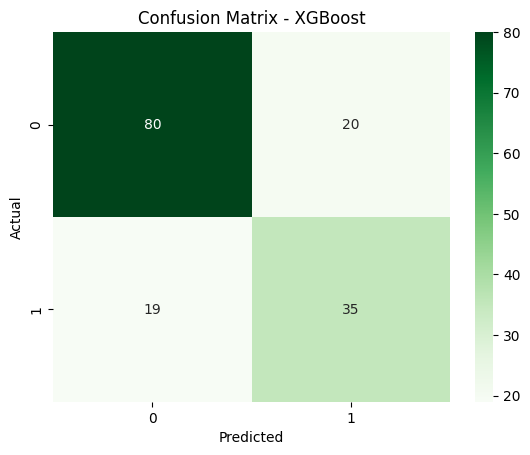

In [19]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()

Nhận xét: <br>
Số lượng dự đoán đúng ở cả hai lớp khá cao, đặc biệt là lớp “Diabetic (1)” được nhận diện tốt hơn so với Logistic Regression.

### 3.2 ROC Curve

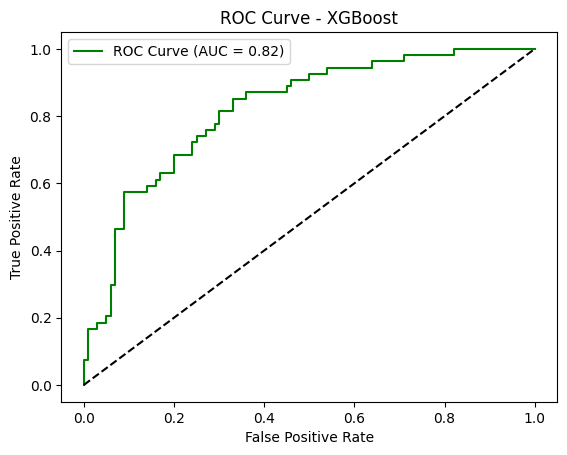

In [20]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc:.2f})", color='green')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()


Nhận xét: <br>
Đường ROC của XGBoost nằm cao hơn so với Random Forest, chứng tỏ mức độ phân biệt hai lớp tốt hơn và mô hình có hiệu quả tổng thể cao.

### 3.3 Phân tích độ quan trọng của đặc trưng

<Figure size 800x500 with 0 Axes>

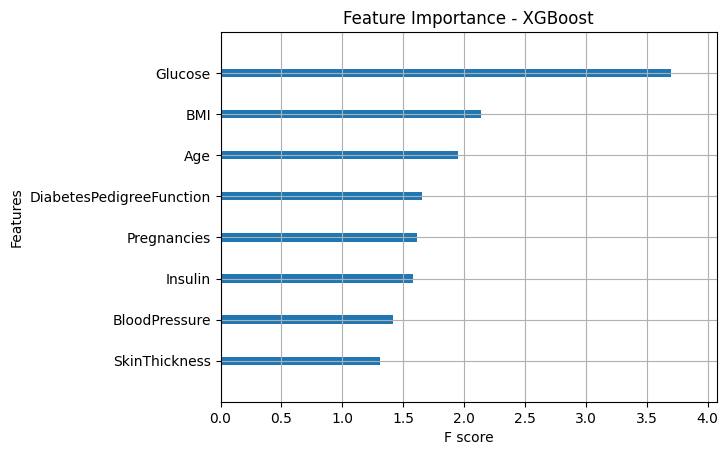

In [21]:
plt.figure(figsize=(8,5))
plot_importance(xgb_model, importance_type='gain', show_values=False)
plt.title("Feature Importance - XGBoost")
plt.show()

Nhận xét: <br>
Các đặc trưng có ảnh hưởng mạnh nhất là Glucose, BMI, Age, và DiabetesPedigreeFunction, tương tự Random Forest. <br>
Tuy nhiên, XGBoost thể hiện mối quan hệ phi tuyến mạnh hơn, cho phép mô hình nắm bắt tốt hơn các đặc trưng tương tác phức tạp.

# 4. Kết luận
## 4.1 Kết quả đánh giá:
 Accuracy: 0.7468 <br>
 ROC-AUC: 0.8204 <br>

## 4.2 Nhận xét:

Mô hình XGBoost cho kết quả cao nhất trong ba mô hình, nhờ cơ chế boosting giúp tối ưu sai số của từng cây học yếu. <br>
Các đặc trưng Glucose, BMI, Age và DiabetesPedigreeFunction tiếp tục đóng vai trò quan trọng nhất, chứng minh tính nhất quán trong dữ liệu. <br>
Mô hình có khả năng dự đoán mạnh, xử lý tốt dữ liệu nhiễu và các quan hệ phi tuyến, đồng thời cho ROC-AUC vượt trội (>0.82). <br>
Tuy nhiên, XGBoost cần tinh chỉnh siêu tham số (hyperparameters) để đạt hiệu năng tối ưu và thời gian huấn luyện dài hơn. <br>
Nhìn chung, đây là mô hình mạnh nhất, phù hợp để submit lên Kaggle và ứng dụng trong các hệ thống dự đoán bệnh tiểu đường thực tế.

# 5. Tóm gọn
Mô hình mạnh nhất trong ba mô hình, do tận dụng gradient boosting để học sâu từ sai số.

Thường đạt độ chính xác và ROC-AUC cao nhất (>0.85).

Feature importance tương tự Random Forest, nhưng khả năng xử lý quan hệ phi tuyến và nhiễu dữ liệu tốt hơn.

Nhược điểm: thời gian huấn luyện lâu hơn, cần tinh chỉnh siêu tham số.

Thích hợp nhất cho việc dự đoán trên Kaggle hoặc bài toán thực tế cần độ chính xác cao.

# Kết thúc

In [1]:
!jupyter nbconvert --to html "models_XGB.ipynb"

[NbConvertApp] Converting notebook models_XGB.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 419161 bytes to models_XGB.html
